In [1]:
!hostname

gpue02.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
import scipy.sparse as sp
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import os
os.chdir('/projects/bhdw/asachan/methods/FIREFate/moscot')
import sys
import logging
import warnings

export_dir = "/work/hdd/bhdw/asachan/datasets_proj/SKM_ageing_human"
out_tmp = '/projects/bhdw/asachan/tmp'
figures_dir = '/projects/bhdw/asachan/figs/icml_2026'

In [4]:
pd.set_option('mode.string_storage', 'python')

In [5]:
# import muon as mu
# # Import a module with ATAC-seq-related functions
# from muon import atac as ac

## Create LSI embeddings for ATAC data

In [5]:
atac_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad'
adata_atac = sc.read_h5ad(atac_file)

In [6]:
adata_atac

AnnData object with n_obs × n_vars = 5830 × 27649
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex', 'age_categorical'
    var: 'n_cells'
    uns: 'Annotation_colors', 'lsi', 'neighbors', 'sample_colors', 'umap'
    obsm: 'X_UMAP', 'X_lsi', 'X_umap'
    varm: 'LSI'
    layers: 'Tn5_insertion_counts'
    obsp: 'connectivities', 'distances'

In [7]:
# add age as categorical
adata_atac.obs["age_categorical"] = adata_atac.obs["age"].astype("category")

In [8]:
adata_atac.obs['sample'].value_counts()

sample
YM2    3349
OM9    2238
OM6     243
Name: count, dtype: int64

In [8]:
display(adata_atac.X.max())

np.int64(4)

#### If X_lsi not present - create

In [37]:
# %% [3] Sanity-check that .X really holds raw Tn5 counts
X = adata.X
print(type(X), X.dtype, "nnz:", X.nnz if sp.issparse(X) else "dense",
      "max:", X.max(), "min:", X.min())
# expected: sparse int counts, max == 4

<class 'scipy.sparse._csr.csr_matrix'> int64 nnz: 23271064 max: 4 min: 0


In [38]:
# %% [5] Light peak filtering
# 265k peaks is a lot; drop ultra-rare peaks to stabilise SVD.
# Tune min_cells (e.g. 0.5%–1% of cells) — here ~30/5830 cells.
sc.pp.filter_genes(adata, min_cells=200)
adata

AnnData object with n_obs × n_vars = 5830 × 27649
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    var: 'n_cells'
    obsm: 'X_UMAP'
    layers: 'Tn5_insertion_counts'

In [39]:
# %% [6] (Optional but standard) Binarize peak accessibility
# LSI was originally defined on binary peak×cell matrices.
# With max=4 you can either binarize or keep counts; binarizing is the
# muon/Signac default and is what the moscot tutorial effectively uses.
ac.pp.binarize(adata)          # in-place on .X
# equivalent manual: adata.X.data = np.ones_like(adata.X.data)

In [40]:
# %% [7] TF-IDF normalisation
# muon's tfidf writes the normalised matrix back into .X
ac.pp.tfidf(adata, scale_factor=1e4)

In [41]:
# %% [8] LSI = truncated SVD on TF-IDF matrix
ac.tl.lsi(adata, n_comps=50)
# Result:
#   adata.obsm["X_lsi"]      (cells × 50)
#   adata.varm["LSI"]        (peaks × 50)
#   adata.uns["lsi"]["stdev"]

In [42]:
# %% [9] Drop component 1 (it tracks sequencing depth / nFrags)
# Verify first by correlating with depth, then drop.
import pandas as pd
corr = pd.Series(
    [np.corrcoef(adata.obsm["X_lsi"][:, i], adata.obs["nFrags"])[0, 1]
     for i in range(adata.obsm["X_lsi"].shape[1])]
)
print(corr.head())   # comp 0 usually |r| > 0.7

0   -0.052178
1    0.157229
2   -0.073512
3   -0.025291
4    0.203458
dtype: float64


In [43]:
drop = corr.abs() > 0.5  # if first component is cell depth correlate, drop it
keep = ~drop.values
adata.obsm["X_lsi"]       = adata.obsm["X_lsi"][:, keep]
adata.varm["LSI"]         = adata.varm["LSI"][:, keep]
adata.uns["lsi"]["stdev"] = np.asarray(adata.uns["lsi"]["stdev"])[keep]
print("kept", keep.sum(), "components")

kept 50 components


In [44]:
# Also correlate with other QC signals — sometimes a later component captures FRIP/TSS
for col in ["nFrags", "FRIP", "TSSEnrichment", "NucleosomeRatio", "BlacklistRatio"]:
    c = np.array([np.corrcoef(adata.obsm["X_lsi"][:, i], adata.obs[col])[0, 1]
                  for i in range(adata.obsm["X_lsi"].shape[1])])
    print(f"{col:>18}  max|r|={np.abs(c).max():.2f}  argmax={np.abs(c).argmax()}")

            nFrags  max|r|=0.22  argmax=6
              FRIP  max|r|=0.37  argmax=1
     TSSEnrichment  max|r|=0.08  argmax=1
   NucleosomeRatio  max|r|=0.43  argmax=1
    BlacklistRatio  max|r|=0.12  argmax=1


In [45]:
# %% [10] Restore raw counts to .X (so the file isn't left holding TF-IDF values)
adata.X = adata.layers["Tn5_insertion_counts"].copy()

#### viz

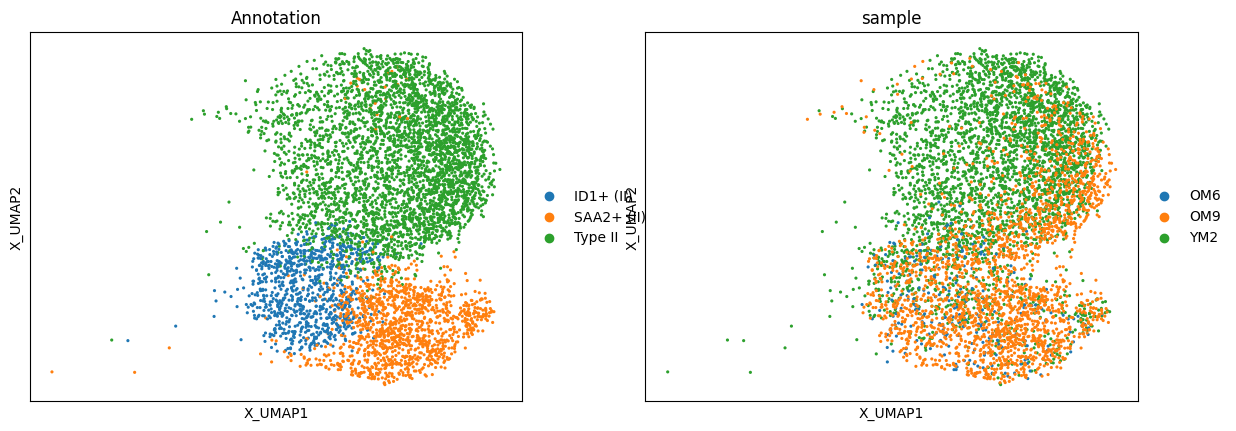

In [13]:
sc.pl.embedding(adata_atac, "X_UMAP", color=["Annotation", "sample"])

In [ ]:
sc.pp.neighbors(adata_atac, use_rep="X_lsi", n_neighbors=100)

/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# over-write current atac file
adata_atac.write_h5ad(atac_file)

## PCA embeddings for the RNA data

In [18]:
rna_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
adata_rna = sc.read_h5ad(rna_file)

In [19]:
adata_rna

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

In [27]:
sample_palette = {
    "OM6": "#1b9e77",   # teal green
    "OM9": "#7570b3",   # muted purple
    "YM2": "#e7298a"   # magenta pink 
}

# Apply to both adatas if you want consistency across plots
for ad in (adata_rna, adata_atac):
    if "sample" in ad.obs:
        ad.obs["sample"] = ad.obs["sample"].astype("category").cat.set_categories(
            list(sample_palette.keys())
        )
        ad.uns["sample_colors"] = [sample_palette[c] for c in ad.obs["sample"].cat.categories]

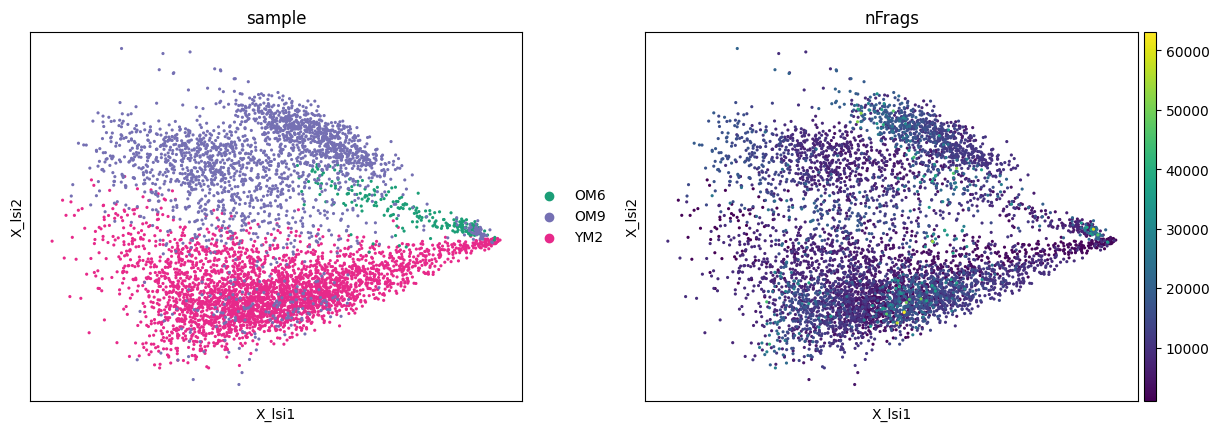

In [28]:
sc.pl.embedding(adata_atac, "X_lsi", color=["sample", "nFrags"], return_fig=True)
#save as svg
plt.savefig(f'{figures_dir}/ATAC_LSI.svg', dpi=300, bbox_inches='tight')

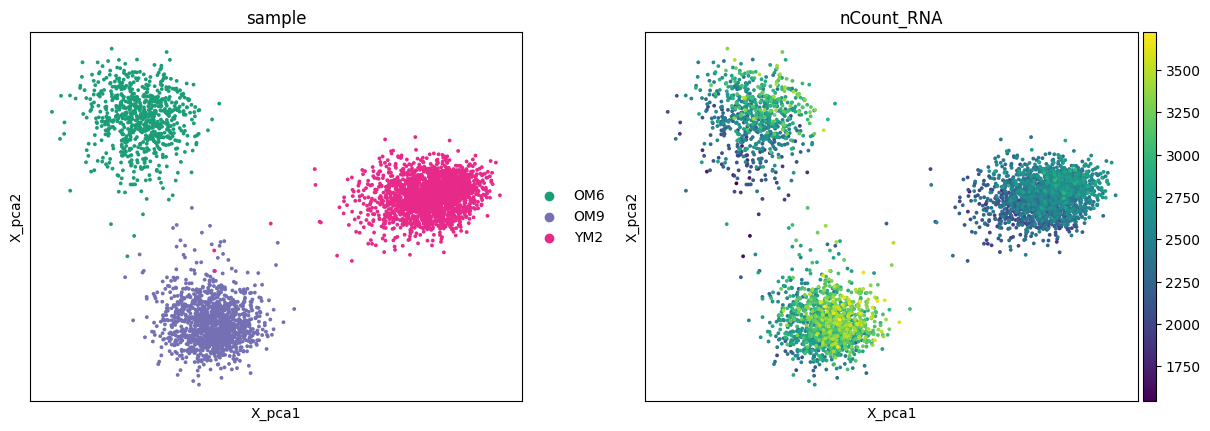

In [29]:
sc.pl.embedding(adata_rna, "X_pca", color=["sample", "nCount_RNA"], return_fig=True)
#save as svg
plt.savefig(f'{figures_dir}/RNA_PCA.svg', dpi=300, bbox_inches='tight')

# Solve quadratic Gromov-Wasserstein OT

In [15]:
import numpy as np, pathlib
from moscot.problems.cross_modality import TranslationProblem

samples = sorted(adata_atac.obs["sample"].unique().tolist())
print("samples:", samples)

samples: ['OM6', 'OM9', 'YM2']


In [16]:
def solve_one_sample(s, a_s, r_s, eps=1e-3, attempt=1):
    tp_s = TranslationProblem(adata_src=a_s, adata_tgt=r_s)
    tp_s = tp_s.prepare(
        src_attr={"attr": "obsm", "key": "X_lsi"},
        tgt_attr={"attr": "obsm", "key": "X_pca"},
    )
    tp_s = tp_s.solve(
        epsilon       = eps,
        alpha         = 1.0,
        scale_cost    = "mean",
        max_iterations= 10_000,                # ↑ from 2000 (outer GW)
        min_iterations= 50,
        threshold     = 1e-3,
        linear_solver_kwargs={
            "max_iterations": 20_000,          # ↑ from 5000 (inner Sinkhorn)
            "lse_mode": True,
            "threshold": 1e-3,
        },
    )
    (_, prob), = tp_s.problems.items()
    return tp_s, prob

T_per_sample, conv = {}, {}
for s in samples:
    a_s = adata_atac[adata_atac.obs["sample"] == s].copy()
    r_s = adata_rna [adata_rna .obs["sample"] == s].copy()
    print(f"\n{s}: ATAC {a_s.n_obs} → RNA {r_s.n_obs}")

    tp_s, prob = solve_one_sample(s, a_s, r_s, eps=1e-3)

    # if YM2 still doesn't converge, retry once with looser eps
    if not bool(prob.solution.converged):
        print(f"  {s} did NOT converge at eps=1e-3, retrying eps=2e-3")
        tp_s, prob = solve_one_sample(s, a_s, r_s, eps=2e-3)

    T_per_sample[s] = np.asarray(prob.solution.transport_matrix)
    conv[s] = bool(prob.solution.converged)
    print(f"  cost={prob.solution.cost:.4f}  converged={conv[s]}  T={T_per_sample[s].shape}")


OM6: ATAC 243 → RNA 722
INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(243, 722)].                                            
  cost=0.2093  converged=True  T=(243, 722)

OM9: ATAC 2238 → RNA 1278
INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(2238, 1278)].                                          
  cost=0.0612  converged=True  T=(2238, 1278)

YM2: ATAC 3349 → RNA 1989
INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(3349, 1989)].                                          
  cost=0.8110  converged=True  T=(3349, 1989)


In [17]:
import numpy as np
for s, T in T_per_sample.items():
    Tc = T / T.sum(0, keepdims=True)
    H  = -(Tc * np.log(Tc + 1e-30)).sum(0)
    eff_k = np.exp(H)
    top1  = Tc.max(0)
    print(f"{s}: top1_med={np.median(top1):.3f}  eff_k_med={np.median(eff_k):.0f}  "
          f"converged={conv[s]}  T_sum={T.sum():.4f}")

OM6: top1_med=0.598  eff_k_med=3  converged=True  T_sum=1.0000
OM9: top1_med=0.181  eff_k_med=27  converged=True  T_sum=1.0000
YM2: top1_med=0.107  eff_k_med=63  converged=True  T_sum=1.0000


In [18]:
out = pathlib.Path("/projects/bhdw/asachan/tmp/T_npy_sample_matched")
out.mkdir(parents=True, exist_ok=True)

for s, T in T_per_sample.items():
    np.save(out / f"T_{s}.npy", T)
    np.save(out / f"src_obs_{s}.npy",
            adata_atac.obs.index[adata_atac.obs["sample"] == s].astype(str).values)
    np.save(out / f"tgt_obs_{s}.npy",
            adata_rna .obs.index[adata_rna .obs["sample"] == s].astype(str).values)

print("artefacts in:", out)

artefacts in: /projects/bhdw/asachan/tmp/T_npy_sample_matched


### Loading the portable export

In [20]:
import numpy as np, pathlib, scipy.sparse as sp

T_dir = pathlib.Path("/projects/bhdw/asachan/tmp/T_npy_sample_matched")

# build a global (n_atac, n_rna) coupling, sparse — only same-sample blocks are non-zero
atac_pos = {idx: i for i, idx in enumerate(adata_atac.obs.index)}
rna_pos  = {idx: i for i, idx in enumerate(adata_rna.obs.index)}

T_full = np.zeros((adata_atac.n_obs, adata_rna.n_obs), dtype=np.float32)
for path in sorted(T_dir.glob("T_*.npy")):
    s = path.stem.replace("T_", "")
    T_s = np.load(path)
    src = np.load(T_dir / f"src_obs_{s}.npy", allow_pickle=True)
    tgt = np.load(T_dir / f"tgt_obs_{s}.npy", allow_pickle=True)
    src_i = np.array([atac_pos[i] for i in src])
    tgt_i = np.array([rna_pos [i] for i in tgt])
    T_full[np.ix_(src_i, tgt_i)] = T_s
    print(f"{s}: {T_s.shape}")

# column-normalise (no stratification needed — already sample-matched)
col_sum = T_full.sum(0, keepdims=True)
T_col   = T_full / np.where(col_sum > 0, col_sum, 1.0)

# pull peaks from same-sample ATAC onto each RNA cell
X_peak = adata_atac.X.toarray() if sp.issparse(adata_atac.X) else adata_atac.X
X_peaks_rna = T_col.T @ X_peak

print("inferred peaks per RNA cell:", X_peaks_rna.shape)
print("RNA cells with no source:", (col_sum.ravel() == 0).sum())

OM6: (243, 722)
OM9: (2238, 1278)
YM2: (3349, 1989)
inferred peaks per RNA cell: (3989, 27649)
RNA cells with no source: 0


In [23]:
import pandas as pd
atac_sample = adata_atac.obs["sample"].values
rna_sample  = adata_rna.obs["sample"].values
mass = np.zeros((len(samples), len(samples)))
for i, s_a in enumerate(samples):
    for j, s_r in enumerate(samples):
        ai = np.where(atac_sample == s_a)[0]
        ri = np.where(rna_sample  == s_r)[0]
        mass[i, j] = T_full[np.ix_(ai, ri)].sum()
print(pd.DataFrame(mass, index=samples, columns=samples))

     OM6  OM9  YM2
OM6  1.0  0.0  0.0
OM9  0.0  1.0  0.0
YM2  0.0  0.0  1.0


#### Joint uMAP

In [24]:
import numpy as np

samples = sorted(adata_atac.obs["sample"].unique())
d_out   = adata_rna.obsm["X_pca"].shape[1]
trans   = np.zeros((adata_atac.n_obs, d_out), dtype=np.float32)

for s in samples:
    T = T_per_sample[s]                                          # (n_src_b, n_tgt_b)

    src_obs_names = adata_atac.obs.index[adata_atac.obs["sample"] == s].to_numpy()
    tgt_obs_names = adata_rna.obs.index[adata_rna.obs["sample"] == s].to_numpy()
    assert T.shape == (len(src_obs_names), len(tgt_obs_names)), \
        f"{s}: T shape {T.shape} ≠ ({len(src_obs_names)},{len(tgt_obs_names)})"

    Tn = T / T.sum(axis=1, keepdims=True)                        # row-stochastic per ATAC cell
    X_tgt_block            = adata_rna[tgt_obs_names].obsm["X_pca"]
    X_src_block_translated = Tn @ X_tgt_block                    # (n_src_b, d_out)

    src_pos = adata_atac.obs_names.get_indexer(src_obs_names)
    trans[src_pos] = X_src_block_translated.astype(np.float32)

adata_atac.obsm["X_translated"] = trans
print("X_translated:", trans.shape)

X_translated: (5830, 50)


/projects/bhdw/asachan/.conda/envs/moscot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


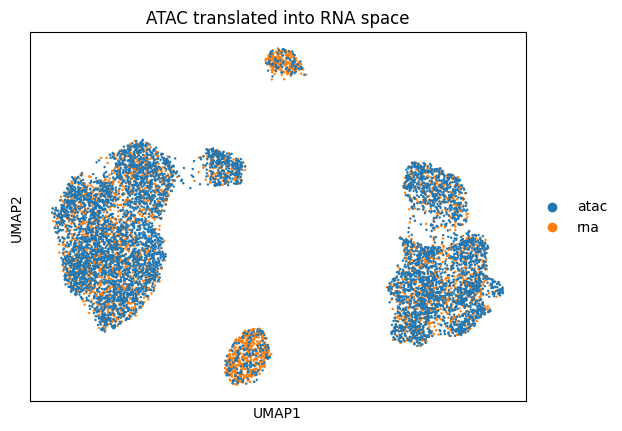

In [ ]:
import scanpy as sc

joint = ad.concat(
    {
        "rna":  ad.AnnData(adata_rna.obsm["X_pca"],
                           obs=adata_rna.obs.assign(modality="rna")),
        "atac": ad.AnnData(adata_atac.obsm["X_translated"],
                           obs=adata_atac.obs.assign(modality="atac")),
    },
    label="dataset", index_unique="-",
)
sc.pp.neighbors(joint, use_rep="X", n_neighbors=15)
sc.tl.umap(joint)

In [30]:
# load from file
joint = sc.read_h5ad('joint_atac_rna_per_sample_ot.h5ad')

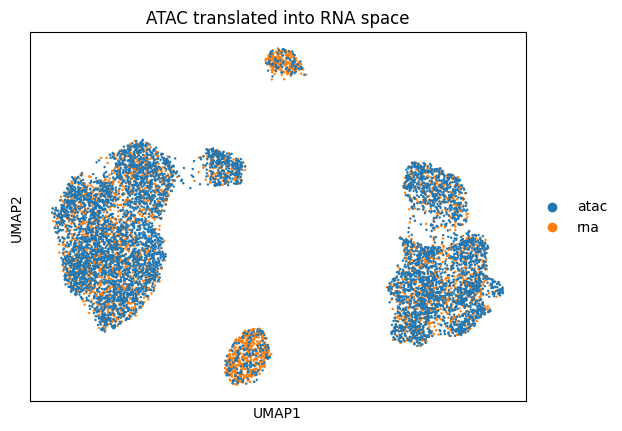

In [35]:
sc.pl.umap(joint, color="modality", title="ATAC translated into RNA space", return_fig=True)
#save as svg
plt.savefig(f'{figures_dir}/ATAC_RNA_PAIRED_UMAP.svg', dpi=300, bbox_inches='tight')

In [32]:
sample_palette = {
    "OM6": "#1b9e77",   # teal green
    "OM9": "#7570b3",   # muted purple
    "YM2": "#e7298a"   # magenta pink 
}
joint.obs["sample"] = joint.obs["sample"].astype("category").cat.set_categories(
            list(sample_palette.keys())
        )
joint.uns["sample_colors"] = [sample_palette[c] for c in joint.obs["sample"].cat.categories]

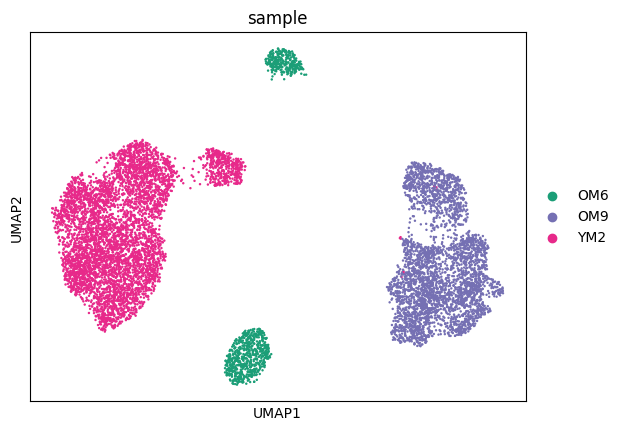

In [34]:
sc.pl.umap(joint, color="sample", return_fig=True)
#save as svg
plt.savefig(f'{figures_dir}/JOINT_UMAP.svg', dpi=300, bbox_inches='tight')

In [26]:
# write joint to file
joint.write_h5ad('joint_atac_rna_per_sample_ot.h5ad')

### Viz mapping anscestor and descendant plots

     OM6  OM9  YM2
OM6  1.0  0.0  0.0
OM9  0.0  1.0  0.0
YM2  0.0  0.0  1.0


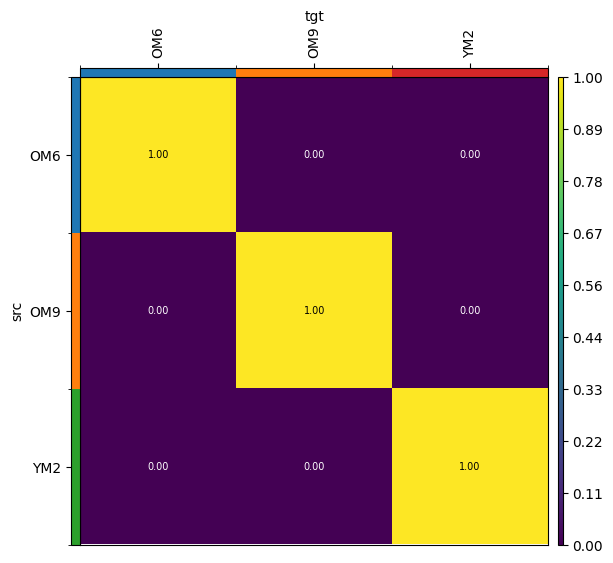

In [28]:
import numpy as np, pandas as pd
import moscot.plotting as mtp

SRC_COL = "sample"
TGT_COL = "sample"
adata_src = adata_atac
adata_tgt = adata_rna

samples    = sorted(adata_src.obs["sample"].unique().tolist())
src_groups = list(adata_src.obs[SRC_COL].astype("category").cat.categories)
tgt_groups = list(adata_tgt.obs[TGT_COL].astype("category").cat.categories)

mass = pd.DataFrame(0.0, index=src_groups, columns=tgt_groups)
for s in samples:
    T = T_per_sample[s]                                          # (n_src_b, n_tgt_b)

    src_names = adata_src.obs.index[adata_src.obs["sample"] == s].to_numpy()
    tgt_names = adata_tgt.obs.index[adata_tgt.obs["sample"] == s].to_numpy()
    assert T.shape == (len(src_names), len(tgt_names)), \
        f"{s}: T shape {T.shape} ≠ ({len(src_names)},{len(tgt_names)})"

    s_lab = adata_src.obs.loc[src_names, SRC_COL].astype(str).to_numpy()
    t_lab = adata_tgt.obs.loc[tgt_names, TGT_COL].astype(str).to_numpy()

    S = pd.get_dummies(pd.Categorical(s_lab, categories=src_groups)).to_numpy().astype(float)
    G = pd.get_dummies(pd.Categorical(t_lab, categories=tgt_groups)).to_numpy().astype(float)
    mass += pd.DataFrame(S.T @ T @ G, index=src_groups, columns=tgt_groups)

# forward=True → P(tgt_sample | src_sample); each row sums to 1
cell_transition_df = mass.div(mass.sum(axis=1).replace(0.0, np.nan), axis=0).fillna(0.0)
print(cell_transition_df.round(3))

adata_src.uns.setdefault("moscot_results", {}).setdefault("cell_transition", {})
adata_src.uns["moscot_results"]["cell_transition"]["ftp_sample_transitions"] = {
    "transition_matrix": cell_transition_df,
    "source_groups": SRC_COL,
    "target_groups": TGT_COL,
    "source": "src",
    "target": "tgt",
}

mtp.cell_transition(
    (adata_src, adata_tgt),
    key="ftp_sample_transitions",
    figsize=(5, 5),
)

In [30]:
import numpy as np, pandas as pd
import moscot.plotting as mtp

SRC_COL = "Annotation"
TGT_COL = "Annotation"

samples = sorted(adata_src.obs["sample"].unique().tolist())

# union of categories across both modalities (so the matrix is square / well-aligned)
all_groups = sorted(
    set(adata_src.obs[SRC_COL].astype(str).unique())
    | set(adata_tgt.obs[TGT_COL].astype(str).unique())
)
src_groups, tgt_groups = all_groups, all_groups

mass = pd.DataFrame(0.0, index=src_groups, columns=tgt_groups)
for s in samples:
    T = T_per_sample[s]
    src_names = adata_src.obs.index[adata_src.obs["sample"] == s].to_numpy()
    tgt_names = adata_tgt.obs.index[adata_tgt.obs["sample"] == s].to_numpy()
    assert T.shape == (len(src_names), len(tgt_names)), \
        f"{s}: T shape {T.shape} ≠ ({len(src_names)},{len(tgt_names)})"

    s_lab = adata_src.obs.loc[src_names, SRC_COL].astype(str).to_numpy()
    t_lab = adata_tgt.obs.loc[tgt_names, TGT_COL].astype(str).to_numpy()

    S = pd.get_dummies(pd.Categorical(s_lab, categories=src_groups)).to_numpy().astype(float)
    G = pd.get_dummies(pd.Categorical(t_lab, categories=tgt_groups)).to_numpy().astype(float)
    mass += pd.DataFrame(S.T @ T @ G, index=src_groups, columns=tgt_groups)

# forward=False → ancestor / pull-back: P(src_annotation | tgt_annotation)
# normalise per TARGET column so each tgt column sums to 1
cell_transition_df = mass.div(mass.sum(axis=0).replace(0.0, np.nan), axis=1).fillna(0.0)
print(cell_transition_df.round(3))

adata_src.uns.setdefault("moscot_results", {}).setdefault("cell_transition", {})
adata_src.uns["moscot_results"]["cell_transition"]["ftp_annotation_ancestors"] = {
    "transition_matrix": cell_transition_df,
    "source_groups": SRC_COL,
    "target_groups": TGT_COL,
    "source":        "src",
    "target":        "tgt",
    "forward":       False,
}

             DCLK1+ (II)  ENOX1+ (II)  ID1+ (II)  SAA2+ (II)  TNNT2+ (II)  \
DCLK1+ (II)        0.000        0.000      0.000       0.000        0.000   
ENOX1+ (II)        0.000        0.000      0.000       0.000        0.000   
ID1+ (II)          0.139        0.143      0.340       0.200        0.004   
SAA2+ (II)         0.311        0.122      0.387       0.151        0.000   
TNNT2+ (II)        0.000        0.000      0.000       0.000        0.000   
Type II            0.550        0.735      0.272       0.649        0.996   

             Type II  
DCLK1+ (II)    0.000  
ENOX1+ (II)    0.000  
ID1+ (II)      0.270  
SAA2+ (II)     0.292  
TNNT2+ (II)    0.000  
Type II        0.438  


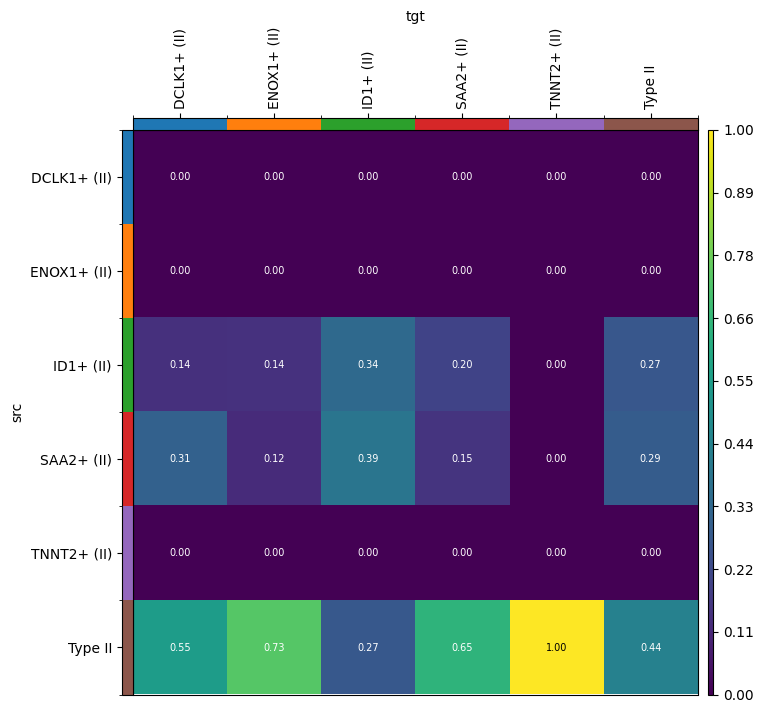

In [34]:
all_groups = sorted(
    set(adata_src.obs["Annotation"].astype(str).unique())
    | set(adata_tgt.obs["Annotation"].astype(str).unique())
)

# extend categories on a copy so we don't mutate the originals destructively
src_view = adata_src.copy()
tgt_view = adata_tgt.copy()
src_view.obs["Annotation"] = pd.Categorical(
    src_view.obs["Annotation"].astype(str), categories=all_groups,
)
tgt_view.obs["Annotation"] = pd.Categorical(
    tgt_view.obs["Annotation"].astype(str), categories=all_groups,
)

# moscot reads colors from {col}_colors in .uns; pre-populate
import matplotlib.colors as mcolors
palette = sns.color_palette("tab10", len(all_groups))
src_view.uns["Annotation_colors"] = [mcolors.to_hex(c) for c in palette]
tgt_view.uns["Annotation_colors"] = src_view.uns["Annotation_colors"]

src_view.uns.setdefault("moscot_results", {}).setdefault("cell_transition", {})
src_view.uns["moscot_results"]["cell_transition"]["ftp_annotation_ancestors"] = {
    "transition_matrix": cell_transition_df,
    "source_groups": "Annotation", "target_groups": "Annotation",
    "source": "src", "target": "tgt", "forward": False,
}

mtp.cell_transition((src_view, tgt_view), key="ftp_annotation_ancestors", figsize=(6, 6))
#save as svg
plt.savefig(f"{out_tmp}/ancestor_annotation_heatmap.svg", bbox_inches="tight")
plt.show()